<div align='center'>

# 🗺️ Layout Cartográfico — Cuenca del Huasco
**Elevación (SRTM) · NDVI medio (MODIS) · Cuenca · Región de Atacama**

</div>

## 0 · Dependencias
> Solo instala lo que falte — no requiere reiniciar el runtime.

In [30]:
import importlib.util, os

def install_if_missing(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f'Instalando {pip_name}...')
        os.system(f'pip install -q {pip_name}')
        print(f'✅ {pip_name} instalado')
    else:
        print(f'✅ {pip_name} ya está disponible')

install_if_missing('ee',                  'earthengine-api')
install_if_missing('geemap',              'geemap')
install_if_missing('matplotlib_scalebar', 'matplotlib-scalebar')
install_if_missing('cartopy',             'cartopy')
install_if_missing('geopandas',           'geopandas')
install_if_missing('PIL',                 'Pillow')

✅ earthengine-api ya está disponible
✅ geemap ya está disponible
✅ matplotlib-scalebar ya está disponible
✅ cartopy ya está disponible
✅ geopandas ya está disponible
✅ Pillow ya está disponible


## 1 · Imports e inicialización de Earth Engine
> El proyecto se lee desde los **Secrets de Colab** (`🔑 → projectGEE`). Si no lo tienes configurado, reemplaza `userdata.get(...)` por el string de tu proyecto directamente.

In [31]:
import ee, geemap, numpy as np, warnings, requests
import geopandas as gpd
from shapely.geometry import shape
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from google.colab import userdata
# Silenciar solo advertencias de proyecciones de Cartopy y GeoPandas
warnings.filterwarnings('ignore', category=UserWarning, module='cartopy')
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')
warnings.filterwarnings('ignore', message='.*CRS.*')

PROJECT_ID = userdata.get('projectGEE')

try:
    ee.Initialize(project=PROJECT_ID)
    print(f'✅ Earth Engine inicializado — proyecto: {PROJECT_ID}')
except Exception:
    print('Autenticando...')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print(f'✅ Earth Engine inicializado tras autenticación — proyecto: {PROJECT_ID}')

✅ Earth Engine inicializado — proyecto: guillermofuentes


## 2 · Geometrías: Provincia y Cuenca del Huasco

In [32]:
# ── Regiones de contexto (Atacama y Coquimbo) ─────────────────────────────────
regiones = (
    ee.FeatureCollection('FAO/GAUL/2015/level1')
    .filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
    .filter(ee.Filter.inList('ADM1_NAME', ['Atacama', 'Coquimbo']))
)

# ── Provincia y cuenca del Huasco ─────────────────────────────────────────────
gaul = ee.FeatureCollection('FAO/GAUL/2015/level2')

huasco_prov = (
    gaul
    .filter(ee.Filter.eq('ADM0_NAME', 'Chile'))
    .filter(ee.Filter.eq('ADM2_NAME', 'Huasco'))
    .geometry()
)

outlet       = ee.Geometry.Point([-71.17, -28.47])   # desembocadura del río Huasco (coordenadas verificadas en HydroSHEDS)
basins       = ee.FeatureCollection('WWF/HydroSHEDS/v1/Basins/hybas_6')
huasco_basin = ee.Feature(basins.filterBounds(outlet).first()).geometry()

# ── AOI: unión provincia + cuenca con buffer 5 km ─────────────────────────────
AOI = huasco_basin.union(huasco_prov).bounds().buffer(5000).bounds()

# ── GeoDataFrames para plotear ────────────────────────────────────────────────
huasco_gdf = gpd.GeoDataFrame(
    geometry=[shape(huasco_basin.getInfo())],
    crs='EPSG:4326'
)
regiones_gdf = gpd.GeoDataFrame(
    geometry=[shape(f['geometry']) for f in regiones.getInfo()['features']],
    crs='EPSG:4326'
)

# ── Ríos desde HydroSHEDS — solo ríos principales ────────────────────────────
rios_region = (
    ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers')
    .filterBounds(regiones.geometry())
    .filter(ee.Filter.lte('RIV_ORD', 6))   # orden 1–5 (menores = más grandes)
    .limit(500)                              # tope de seguridad
)

rios_gdf = gpd.GeoDataFrame(
    geometry=[shape(f['geometry']) for f in rios_region.getInfo()['features']],
    crs='EPSG:4326'
)


print(f'Regiones     — features: {len(regiones_gdf)}')   # debe ser 2
print(f'Prov Huasco  — área > 0: {huasco_prov.area().getInfo() > 0}')
print(f'Ríos región — features: {len(rios_gdf)}')
print('✅ Geometrías y AOI listos')

Regiones     — features: 2
Prov Huasco  — área > 0: True
Ríos región — features: 420
✅ Geometrías y AOI listos


## 3 · Capas: DEM (SRTM) y NDVI medio (MODIS MOD13Q1)

In [33]:
# ── DEM + Hillshade (SRTM 30 m) ───────────────────────────────────────────────
dem = ee.Image('USGS/SRTMGL1_003').clip(AOI)

hillshade = ee.Terrain.hillshade(dem)

elev_vis = {
    'min': -120,
    'max': 4600,
    'palette': [
        '#9fc5e8', '#006837', '#1a9850', '#66bd63', '#a6d96a',
        '#d9ef8b', '#ffffbf', '#fee08b', '#fdae61', '#f46d43',
        '#d73027', '#b2182b', '#f46d43', '#d73027', '#b2182b',
        '#f6e8c3', '#f5f5f5'
    ],
    'opacity': 0.8
}

# Aplicar paleta al DEM
rgb = dem.visualize(**elev_vis)

# Combinar con hillshade para dar relieve
shaded = ee.Image.rgb(
    rgb.select(0).multiply(hillshade.divide(255)),
    rgb.select(1).multiply(hillshade.divide(255)),
    rgb.select(2).multiply(hillshade.divide(255))
)

# ── NDVI medio período de floración (ajusta meses según tu análisis) ───────────
MONTH_START, MONTH_END = 7, 10    # julio–octubre
YEAR_START,  YEAR_END  = 2015, 2019   # sincronizado con notebook de análisis de bloom

ndvi_mean = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
    .filterDate(f'{YEAR_START}-01-01', f'{YEAR_END}-12-31')
    .filter(ee.Filter.calendarRange(MONTH_START, MONTH_END, 'month'))
    .select('NDVI')
    .map(lambda img: img.multiply(0.0001))
    .mean()
    .clip(AOI)
)

print('✅ DEM con hillshade y NDVI procesados.')

✅ DEM con hillshade y NDVI procesados.


## 4 · Descarga de arrays numpy
> Resolución de 1 km para velocidad. Baja a 500 m si quieres más detalle.

In [34]:
# ── Extensión del AOI ─────────────────────────────────────────────────────────
aoi_coords = AOI.bounds().getInfo()['coordinates'][0]
lons = [c[0] for c in aoi_coords]
lats = [c[1] for c in aoi_coords]
dem_ext  = [min(lons), max(lons), min(lats), max(lats)]
ndvi_ext = dem_ext

# ── Shaded DEM via getThumbURL ────────────────────────────────────────────────
# ee.Image.rgb() produce bandas 'vis-red','vis-green','vis-blue' en uint8 (0–255)
thumb_url = shaded.getThumbURL({
    'region':     AOI,
    'dimensions': 1200,
    'format':     'png',
    'crs':        'EPSG:4326',
    'bands':      ['vis-red', 'vis-green', 'vis-blue'],
    'min':        0,
    'max':        255
})
shaded_2d = np.array(Image.open(BytesIO(requests.get(thumb_url, timeout=60).content)).convert('RGB'))

# ── NDVI enmascarado via getThumbURL (RGBA para transparencia) ────────────────
ndvi_url = ndvi_shaded.getThumbURL({
    'region':     AOI,
    'dimensions': 1200,   # misma resolución que DEM para evitar desalineación de grillas
    'format':     'png',
    'crs':        'EPSG:4326',
    'bands':      ['vis-red', 'vis-green', 'vis-blue'],
    'min':        0,
    'max':        255
})
ndvi_2d = np.array(Image.open(BytesIO(requests.get(ndvi_url, timeout=60).content)).convert('RGBA'))

# Transparencia en píxeles blancos (fuera de máscara de cuenca)
# Umbral 240/255: los thumbnails de GEE usan blanco puro (#FFFFFF)
# como fondo fuera del área enmascarada; se convierte en transparencia.
es_blanco = (ndvi_2d[:,:,0] > 240) & (ndvi_2d[:,:,1] > 240) & (ndvi_2d[:,:,2] > 240)
ndvi_2d[es_blanco, 3] = 0

# ── DEM escalar para curvas de nivel (500 m — liviano) ───────────────────────
dem_arr = geemap.ee_to_numpy(dem, region=AOI, scale=500)
dem_2d  = dem_arr[:,:,0] if dem_arr.ndim == 3 else dem_arr

print(f'✅ Arrays descargados')
print(f'   Shaded  : {shaded_2d.shape}  (DEM hillshade RGB)')
print(f'   NDVI    : {ndvi_2d.shape}  (cuenca, RGBA)')
print(f'   DEM     : {dem_2d.shape}  @ 500 m (curvas de nivel)')
print(f'   Extensión: lon [{dem_ext[0]:.2f}, {dem_ext[1]:.2f}] | lat [{dem_ext[2]:.2f}, {dem_ext[3]:.2f}]')

✅ Arrays descargados
   Shaded  : (1125, 1200, 3)  (DEM hillshade RGB)
   NDVI    : (750, 800, 4)  (cuenca, RGBA)
   DEM     : (420, 449)  @ 500 m (curvas de nivel)
   Extensión: lon [-71.64, -69.63] | lat [-29.80, -27.92]


## 5 · Layout cartográfico
> Panel izquierdo: DEM · Panel derecho: NDVI

In [35]:
# flecha de norte
from matplotlib.patches import Circle, Polygon
import numpy as np

def add_wind_rose(parent_ax, box=(0.78, 0.66, 0.20, 0.20),
                  linecolor='#1A1A2E', accent='#6E625C'):
    """
    Rosa de los vientos clásica en un inset cuadrado.
    box = (x0, y0, width, height) en coordenadas relativas del eje padre.
    """
    ax = parent_ax.inset_axes(box, transform=parent_ax.transAxes, zorder=30)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')

    cx, cy = 0.5, 0.5

    def pt(r, ang_deg):
        ang = np.deg2rad(ang_deg)
        # 0° = Norte
        return cx + r * np.sin(ang), cy + r * np.cos(ang)

    # Fondo suave
    ax.add_patch(Circle((cx, cy), 0.49, facecolor='white',
                        edgecolor='none', alpha=0.72, zorder=0))

    # Anillo exterior con marcas
    for ang in range(0, 360, 2):
        r0 = 0.435
        if ang % 45 == 0:
            r1, lw, col = 0.515, 0.9, linecolor
        elif ang % 10 == 0:
            r1, lw, col = 0.485, 0.45, '#666666'
        else:
            r1, lw, col = 0.468, 0.25, '#888888'

        x0, y0 = pt(r0, ang)
        x1, y1 = pt(r1, ang)
        ax.plot([x0, x1], [y0, y1], color=col, lw=lw, zorder=1)

    # Círculos principales
    for r, lw in [(0.44, 1.0), (0.39, 0.9), (0.27, 0.8)]:
        ax.add_patch(Circle((cx, cy), r, facecolor='none',
                            edgecolor=linecolor, linewidth=lw, zorder=2))

    # Segmentación del anillo medio
    for ang in range(0, 360, 15):
        x0, y0 = pt(0.27, ang)
        x1, y1 = pt(0.39, ang)
        ax.plot([x0, x1], [y0, y1], color=linecolor, lw=0.6, zorder=2)

    # Guías exteriores
    for ang in [0, 45, 90, 135, 180, 225, 270, 315]:
        x0, y0 = pt(0.44, ang)
        x1, y1 = pt(0.57, ang)
        ax.plot([x0, x1], [y0, y1], color=linecolor, lw=0.7, zorder=1.5)

    def spike(angle, r_tip, r_base, half_width_deg, fc,
              ec=linecolor, lw=0.8, z=5):
        pts = [
            pt(r_tip, angle),
            pt(r_base, angle - half_width_deg),
            (cx, cy),
            pt(r_base, angle + half_width_deg),
        ]
        ax.add_patch(Polygon(
            pts, closed=True,
            facecolor=fc, edgecolor=ec,
            linewidth=lw, zorder=z, joinstyle='miter'
        ))

    # Puntas principales (8)
    for ang, fc in [
        (0, accent), (45, 'white'), (90, accent), (135, 'white'),
        (180, accent), (225, 'white'), (270, accent), (315, 'white')
    ]:
        if ang % 90 == 0:
            spike(ang, r_tip=0.455, r_base=0.070, half_width_deg=4.8, fc=fc, z=6)
        else:
            spike(ang, r_tip=0.335, r_base=0.055, half_width_deg=4.0, fc=fc, z=6)

    # Puntas secundarias (8)
    for ang in [22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5]:
        spike(ang, r_tip=0.215, r_base=0.042, half_width_deg=3.8,
              fc='white', lw=0.6, z=5)

    # Sol/roseta central
    sun_pts = []
    for i, ang in enumerate(np.arange(0, 360, 22.5)):
        r = 0.060 if i % 2 == 0 else 0.038
        sun_pts.append(pt(r, ang))

    ax.add_patch(Polygon(
        sun_pts, closed=True,
        facecolor=accent, edgecolor=linecolor,
        linewidth=0.8, zorder=7
    ))
    ax.add_patch(Circle((cx, cy), 0.072, facecolor='none',
                        edgecolor=linecolor, linewidth=0.8, zorder=7))
    ax.add_patch(Circle((cx, cy), 0.026, facecolor='white',
                        edgecolor=linecolor, linewidth=0.7, zorder=8))

    # Letras cardinales
    main_kw = dict(fontsize=18, fontfamily='serif', color=linecolor)
    ax.text(*pt(0.575,   0), 'N', ha='center', va='center', **main_kw)
    ax.text(*pt(0.575,  90), 'E', ha='center', va='center', rotation=-90, **main_kw)
    ax.text(*pt(0.575, 180), 'S', ha='center', va='center', **main_kw)
    ax.text(*pt(0.575, 270), 'W', ha='center', va='center', rotation=90, **main_kw)

    # Letras intercardinales
    sub_kw = dict(fontsize=10.5, fontfamily='serif', color=linecolor)
    ax.text(*pt(0.345,  45), 'NE', ha='center', va='center', rotation=-35, **sub_kw)
    ax.text(*pt(0.345, 135), 'SE', ha='center', va='center', rotation=-35, **sub_kw)
    ax.text(*pt(0.345, 225), 'SW', ha='center', va='center', rotation=35,  **sub_kw)
    ax.text(*pt(0.345, 315), 'NW', ha='center', va='center', rotation=35,  **sub_kw)

    return ax

✅ Layout generado.


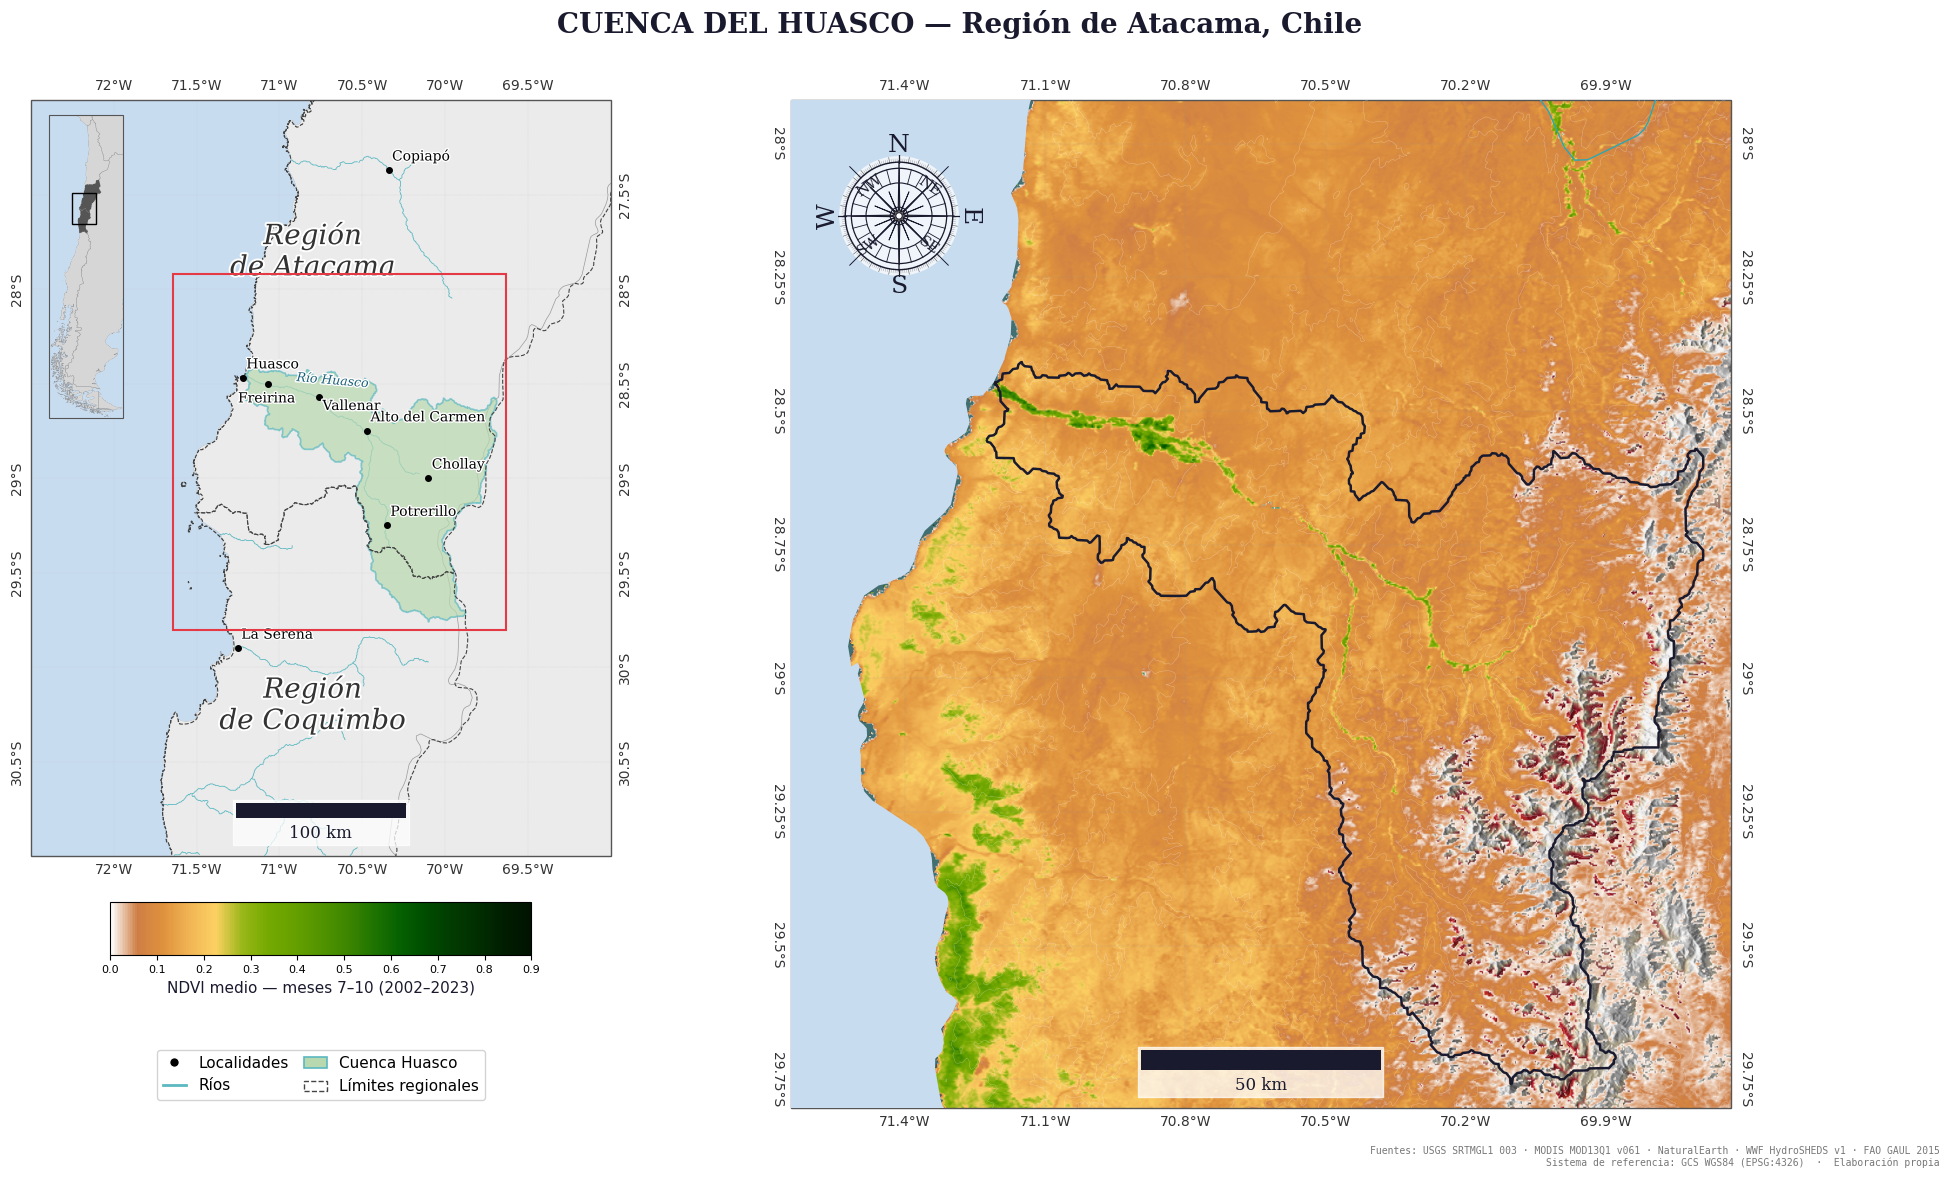

In [36]:
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

CRS = ccrs.PlateCarree()
BG  = '#FFFFFF'

EXT_MAIN = [dem_ext[0], dem_ext[1], dem_ext[2], dem_ext[3]]
EXT_REG  = [-72.5, -69.0, -31.0, -27.0]
EXT_CHL  = [-76.0, -65.0, -56.0, -17.0]

rivers = cfeature.NaturalEarthFeature(
    category='physical', name='rivers_lake_centerlines',
    scale='10m', facecolor='none'
)

# Colormaps para colorbars
paleta_elev = [
    '#9fc5e8', '#006837', '#1a9850', '#66bd63', '#a6d96a',
    '#d9ef8b', '#ffffbf', '#fee08b', '#fdae61', '#f46d43',
    '#d73027', '#b2182b', '#f46d43', '#d73027', '#b2182b',
    '#f6e8c3', '#f5f5f5'
]
paleta_ndvi = [
    '#ffffff', '#ce7e45', '#df923d', '#f1b555', '#fcd163', '#99b718',
    '#74a901', '#66a000', '#529400', '#3e8601', '#207401', '#056201',
    '#004c00', '#023b01', '#012e01', '#011d01', '#011301'
]
sm_elev = ScalarMappable(
    cmap=LinearSegmentedColormap.from_list('elev', paleta_elev),
    norm=mcolors.Normalize(vmin=-120, vmax=4600)
)
sm_elev.set_array([])

sm_ndvi = ScalarMappable(
    cmap=LinearSegmentedColormap.from_list('ndvi', paleta_ndvi),
    norm=mcolors.Normalize(vmin=0, vmax=0.9)
)
sm_ndvi.set_array([])

# ── Figura: 2 columnas, 2 filas (panel reg + leyenda | panel main) ────────────
fig = plt.figure(figsize=(20, 12), facecolor=BG)

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[0.32, 0.68],
    height_ratios=[0.78, 0.22],
    hspace=0.08, wspace=0.0,
    left=0.03, right=0.97, top=0.90, bottom=0.06
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL IZQUIERDO — Regional (fila 0, col 0)
# ══════════════════════════════════════════════════════════════════════════════
ax_reg = fig.add_subplot(gs[0, 0], projection=CRS, facecolor='#C8DCF0')
ax_reg.set_extent(EXT_REG, crs=CRS)

ax_reg.add_feature(cfeature.LAND,    facecolor='#EBEBEB', edgecolor='#aaa', linewidth=0.3)
ax_reg.add_feature(cfeature.OCEAN,   facecolor='#C8DCF0')
ax_reg.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='#999')

rios_gdf.plot(ax=ax_reg, color='#5BB8C1', linewidth=0.6, zorder=3, transform=CRS)

huasco_gdf.plot(ax=ax_reg, color='#B8D9B0', edgecolor='#5BB8C1',
                linewidth=1.2, zorder=4, transform=CRS, alpha=0.7)
regiones_gdf.boundary.plot(ax=ax_reg, color='#444', linewidth=0.8,
                            linestyle='--', zorder=5, transform=CRS)

# Nombres de regiones
nombres_regiones = {
    'Región\nde Atacama':  (-70.8, -27.8),
    'Región\nde Coquimbo': (-70.8, -30.2),
}
for nombre, (lon, lat) in nombres_regiones.items():
    ax_reg.text(lon, lat, nombre, fontsize=20, fontstyle='italic',
                fontfamily='serif', color='#333', ha='center', va='center',
                transform=CRS, zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground='white')])

# Ciudades
ciudades_reg = {
    'Vallenar':        (-70.76, -28.57, +0.02, -0.07),
    'Copiapó':         (-70.34, -27.37, +0.02, +0.05),
    'Freirina':        (-71.07, -28.50, -0.18, -0.10),
    'Huasco':          (-71.22, -28.47, +0.02, +0.05),
    'La Serena':       (-71.25, -29.90, +0.02, +0.05),
    'Alto del Carmen': (-70.47, -28.75, +0.02, +0.05),
    'Chollay':         (-70.10, -29.00, +0.02, +0.05),
    'Potrerillo':      (-70.35, -29.25, +0.02, +0.05),
}
for nombre, (lon, lat, dlon, dlat) in ciudades_reg.items():
    ax_reg.plot(lon, lat, 'ko', markersize=4, transform=CRS, zorder=7)
    ax_reg.text(lon + dlon, lat + dlat, nombre, fontsize=10,
                fontfamily='serif', transform=CRS, zorder=8,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

ax_reg.text(-70.90, -28.52, 'Río Huasco', fontsize=9, color='#1A5F7A',
             fontstyle='italic', fontfamily='serif', transform=CRS, rotation=-5,
             path_effects=[pe.withStroke(linewidth=2, foreground='white')], zorder=8)

# Cuadrícula
gl_r = ax_reg.gridlines(draw_labels=True, linewidth=0.3,
                         color='#bbb', alpha=0.8, linestyle=':')
gl_r.top_labels    = True
gl_r.bottom_labels = True
gl_r.left_labels   = True
gl_r.right_labels  = True
gl_r.xformatter = LONGITUDE_FORMATTER
gl_r.yformatter = LATITUDE_FORMATTER
gl_r.xlabel_style = {'size': 10, 'color': '#333'}
gl_r.ylabel_style = {'size': 10, 'color': '#333', 'rotation': 90}

# Recuadro zoom
x0, x1, y0, y1 = EXT_MAIN
ax_reg.add_patch(Rectangle(
    (x0, y0), x1-x0, y1-y0,
    linewidth=1.5, edgecolor='#E63946', facecolor='none',
    transform=CRS, zorder=9
))

# Escala
lat_centro_reg       = (EXT_REG[2] + EXT_REG[3]) / 2
metros_por_grado_reg = 111320 * np.cos(np.radians(lat_centro_reg))
ax_reg.add_artist(ScaleBar(
    metros_por_grado_reg, units='m',
    fixed_value=100, fixed_units='km',
    location='lower center',
    frameon=True, color='#1A1A2E',
    box_color='white', box_alpha=0.75,
    border_pad=0.8, sep=5, height_fraction=0.02,
    font_properties={'size': 12, 'family': 'serif'}
))

# Inset Chile
ax_chl = ax_reg.inset_axes([-0.08, 0.58, 0.35, 0.40], projection=CRS)
ax_chl.set_extent(EXT_CHL, crs=CRS)
ax_chl.add_feature(cfeature.LAND,    facecolor='#D6D6D6', edgecolor='#888', linewidth=0.3)
ax_chl.add_feature(cfeature.OCEAN,   facecolor='#C8DCF0')
ax_chl.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#888')
regiones_gdf.plot(ax=ax_chl, color='#555', zorder=3, transform=CRS)
x0r, x1r, y0r, y1r = EXT_REG
ax_chl.add_patch(Rectangle(
    (x0r, y0r), x1r-x0r, y1r-y0r,
    linewidth=1.0, edgecolor='black', facecolor='none',
    transform=CRS, zorder=5
))
for spine in ax_chl.spines.values():
    spine.set_edgecolor('#555')
    spine.set_linewidth(0.8)

# ══════════════════════════════════════════════════════════════════════════════
# LEYENDA — debajo del panel izquierdo (fila 1, col 0)
# ══════════════════════════════════════════════════════════════════════════════
ax_leg = fig.add_subplot(gs[1, 0])
ax_leg.axis('off')

# Colorbar NDVI horizontal
cax_ndvi = inset_axes(ax_leg, width='70%', height='25%',
                       loc='upper center', borderpad=0.5)
cb_ndvi  = plt.colorbar(sm_ndvi, cax=cax_ndvi, orientation='horizontal')
cb_ndvi.set_label(
    f'NDVI medio — meses {MONTH_START}–{MONTH_END} ({YEAR_START}–{YEAR_END})',
    fontsize=11, color='#1A1A2E', labelpad=4
)
cb_ndvi.ax.tick_params(labelsize=8)

# Leyenda de símbolos debajo de la colorbar
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='k',
           markersize=7, label='Localidades'),
    Line2D([0],[0], color='#5BB8C1', linewidth=2, label='Ríos'),
    mpatches.Patch(facecolor='#B8D9B0', edgecolor='#5BB8C1',
                   linewidth=1.2, label='Cuenca Huasco'),
    mpatches.Patch(facecolor='none', edgecolor='#444',
                   linewidth=1, linestyle='--', label='Límites regionales'),
]
ax_leg.legend(handles=handles, loc='lower center', ncol=2,
              fontsize=11, frameon=True, framealpha=0.85,
              edgecolor='#ccc', bbox_to_anchor=(0.5, 0.0),
              columnspacing=1.0, handlelength=1.5)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL PRINCIPAL — ocupa ambas filas col 1
# ══════════════════════════════════════════════════════════════════════════════
ax_main = fig.add_subplot(gs[:, 1], projection=CRS, facecolor='#C8DCF0')
ax_main.set_extent(EXT_MAIN, crs=CRS)

# DEM hillshade
ax_main.imshow(
    shaded_2d, extent=dem_ext, transform=CRS,
    origin='upper', interpolation='bilinear', zorder=1
)

# NDVI enmascarado
ax_main.imshow(
    ndvi_2d, extent=ndvi_ext, transform=CRS,
    origin='upper', interpolation='bilinear', zorder=2
)

# Curvas de nivel
lon_arr = np.linspace(dem_ext[0], dem_ext[1], dem_2d.shape[1])
lat_arr = np.linspace(dem_ext[3], dem_ext[2], dem_2d.shape[0])
LON, LAT = np.meshgrid(lon_arr, lat_arr)
ax_main.contour(LON, LAT, dem_2d,
                levels=[500, 1000, 2000, 3000, 4000],
                colors='white', linewidths=0.3, alpha=0.4, transform=CRS, zorder=3)

ax_main.add_feature(rivers, edgecolor='#2AA8B4', linewidth=1.0, zorder=4)
huasco_gdf.boundary.plot(ax=ax_main, color='#1A1A2E', linewidth=1.8,
                          zorder=5, transform=CRS)
ax_main.add_feature(cfeature.OCEAN, facecolor='#C8DCF0', zorder=6)

# Cuadrícula
gl_m = ax_main.gridlines(draw_labels=True, linewidth=0.35,
                          color='#999', alpha=0.7, linestyle=':')
gl_m.top_labels    = True
gl_m.bottom_labels = True
gl_m.left_labels   = True
gl_m.right_labels  = True
gl_m.xformatter = LONGITUDE_FORMATTER
gl_m.yformatter = LATITUDE_FORMATTER
gl_m.xlabel_style = {'size': 10, 'color': '#333'}
gl_m.ylabel_style = {'size': 10, 'color': '#333', 'rotation': 270}

add_wind_rose(
    ax_main,
    box=(0.05, 0.82, 0.13, 0.13),
    linecolor='#1A1A2E',
    accent='#6A5F59'
)

# ax_main.annotate('N', xy=(0.97, 0.97), xytext=(0.97, 0.93),
#                   xycoords='axes fraction', fontsize=15,
#                   ha='center', fontweight='bold', color='#1A1A2E',
#                   arrowprops=dict(arrowstyle='->', color='#1A1A2E', lw=2.2))

lat_centro       = (dem_ext[2] + dem_ext[3]) / 2
metros_por_grado = 111320 * np.cos(np.radians(lat_centro))
ax_main.add_artist(ScaleBar(
    metros_por_grado, units='m',
    fixed_value=50, fixed_units='km',
    location='lower center',
    frameon=True, color='#1A1A2E',
    box_color='white', box_alpha=0.75,
    border_pad=0.8, sep=5, height_fraction=0.02,
    font_properties={'size': 12, 'family': 'serif'}
))

# ax_main.set_title('Cuenca del Río Huasco', fontsize=13,
#                    fontfamily='serif', loc='left', pad=6, color='#1A1A2E')

# ══════════════════════════════════════════════════════════════════════════════
# TÍTULO Y CRÉDITOS
# ══════════════════════════════════════════════════════════════════════════════
fig.text(0.99, 0.01,
    'Fuentes: USGS SRTMGL1 003 · MODIS MOD13Q1 v061 · NaturalEarth · WWF HydroSHEDS v1 · FAO GAUL 2015\n'
    'Sistema de referencia: GCS WGS84 (EPSG:4326)  ·  Elaboración propia',
    ha='right', va='bottom', fontsize=7, color='#777', fontfamily='monospace')

fig.text(0.5, 0.975, 'CUENCA DEL HUASCO — Región de Atacama, Chile',
         ha='center', va='top', fontsize=20, fontweight='bold',
         color='#1A1A2E', fontfamily='serif')

for ax in [ax_reg, ax_main]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
        spine.set_linewidth(1.0)

# Rotar etiquetas Y manualmente tras renderizar
fig.canvas.draw()
for label in gl_r.left_label_artists:
    label.set_rotation(90)
    label.set_ha('center')
    label.set_va('bottom')
for label in gl_m.right_label_artists:
    label.set_rotation(90)
    label.set_ha('center')
    label.set_va('bottom')

print('✅ Layout generado.')
plt.show()


## 6 · Exportar mapa a PNG (300 DPI)

In [37]:
# ── Exportación a PNG ──────────────────────────────────────────────────────
# Cambia EXPORT_PNG = True para guardar la figura en disco y descargarla.
EXPORT_PNG = False

if EXPORT_PNG:
    OUT = '/content/cartografia_huasco.png'
    fig.savefig(OUT, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'✅ Figura guardada en: {OUT}')
    from google.colab import files
    files.download(OUT)
else:
    print("ℹ️  Exportación omitida. Cambia EXPORT_PNG = True para guardar la figura.")